# GT Keyword Extraction and Processing Workflow

In [1]:
# Configuration
dataset_name = "ruoka"
# url_gt = "GT.txt"
# url = "ULR.txt"
dataset_language = "finnish"
base_url = f"https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/{dataset_name}"
num_pages = 100

# Stemming, Compound Analysis, and Stopword Libraries
from nltk.stem.snowball import SnowballStemmer
import nltk
from libvoikko import Voikko  # Finnish compound word analysis
from nltk.corpus import stopwords  # Stopword library

# Initialize stemmer, compound analyzer, and stopwords
stemmer = SnowballStemmer(dataset_language)
voikko_analyzer = Voikko("fi")  # For Finnish compound splitting
nltk_finnish_stopwords = set(stopwords.words(dataset_language))

# Tag rating set
tag_rating_set = {
    "head":  53.0815,
    "title": 53.0815,
    "h1": 50.2844,
    "URL": 47.4130,
    "strong": 17.1284,
    "span": 12.7651,
    "a":  10.6637,
    "ul": 10.3159,
    "li": 10.2524,
    "div":  9.1891,
    "p":  9.1866,
}

In [2]:
import re
def process_keywords(keywords):
    """Apply cleaning, compound splitting, stemming, and stopword filtering to a list of keywords. Returns a processed list of useful words."""
    processed = []
    for word in keywords:
        # Clean word: keep only alphabetic characters (including Finnish letters)
        cleaned_word = re.sub(r'[^a-zA-ZäöåÄÖÅ]', '', word)
        if not cleaned_word:
            continue
        # Compound splitting (Finnish only, using libvoikko)
        compound_parts = [cleaned_word]
        try:
            analyses = voikko_analyzer.analyze(cleaned_word)
            if analyses:
                best = analyses[0]
                # Add baseform if available
                baseform = best.get('BASEFORM')
                if baseform and baseform.lower() != cleaned_word.lower():
                    compound_parts.append(baseform.lower())
                # Add compound parts if available
                wordbases = best.get('WORDBASES', '')
                if wordbases:
                    parts = [p.lower().strip() for p in wordbases.replace(')', '').split('(') if p]
                    compound_parts.extend(parts)
        except Exception:
            pass
        # Clean all compound parts
        cleaned_parts = [re.sub(r'[^a-zA-ZäöåÄÖÅ]', '', part) for part in compound_parts]
        # Remove empty strings after cleaning
        cleaned_parts = [part for part in cleaned_parts if part]
        # Stem all parts
        stemmed_parts = [stemmer.stem(part) for part in cleaned_parts]
        # Filter stopwords
        filtered = [part for part in stemmed_parts if part not in nltk_finnish_stopwords]
        processed.extend(filtered)
    # Return unique processed keywords (useful words only)
    return processed

In [3]:
from bs4 import BeautifulSoup
def extract_and_process_keywords_from_tag(html_text, tag_name):
    """Extracts keywords from the content inside the specified tag in the given HTML text, processes them using process_keywords, and returns a dictionary with keyword frequencies."""
    soup = BeautifulSoup(html_text, 'html.parser')
    elements = soup.find_all(tag_name)
    raw_keywords = []
    for elem in elements:
        text = elem.get_text(separator=' ')
        raw_keywords.extend(text.split())
    processed = process_keywords(raw_keywords)
    freq = {}
    for kw in processed:
        freq[kw] = freq.get(kw, 0) + 1
    return freq

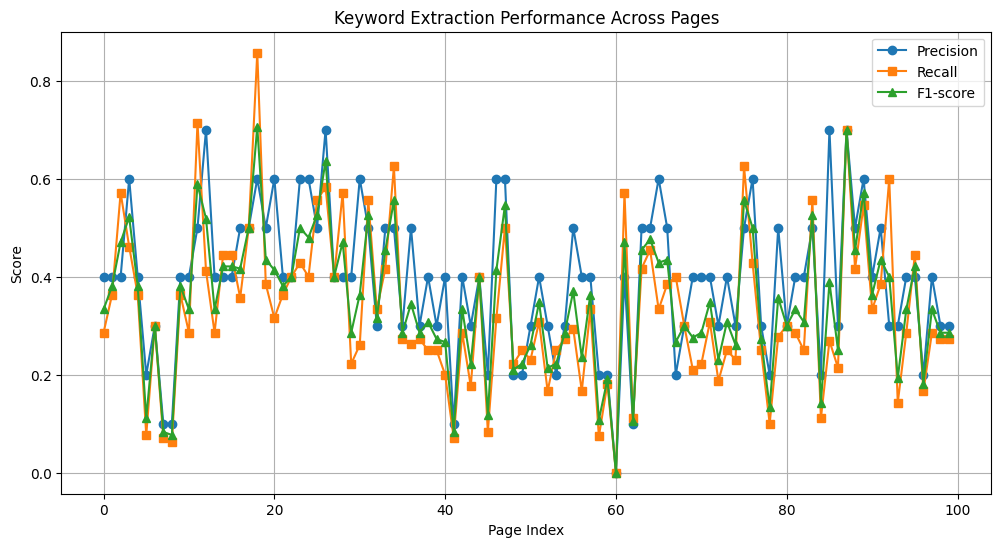


Average Precision: 0.3950
Average Recall: 0.3303
Average F1-score: 0.3501


In [4]:
# 5. Aggregate and Print URL Ratings Across All Pages (as a pseudo-tag for sorting)
from urllib.parse import urlparse, unquote
from collections import defaultdict
import urllib.request
import matplotlib.pyplot as plt

frequency_weight = 5

# Store metrics for all pages
dataset_precisions = []
dataset_recalls = []
dataset_f1s = []

for i in range(num_pages):
    gt_url = f"{base_url}/{i}/GT.txt"
    web_page_url = f"{base_url}/{i}"
    url_file_url = f"{base_url}/{i}/URL.txt"
    processed_gt_keywords = []
    extracting_keywords = {}
    try:
        with urllib.request.urlopen(gt_url, timeout=5) as response:
            gt_text = response.read().decode("utf-8-sig").strip()
            gt_keywords = gt_text.split()
            processed_gt_keywords = list(set(process_keywords(gt_keywords)))
    except Exception as e:
        continue
    # HTML tag ratings
    try:
        with urllib.request.urlopen(web_page_url, timeout=5) as web_response:
            html_text = web_response.read().decode("utf-8-sig").strip()

            for tag, rating in tag_rating_set.items():
                result = extract_and_process_keywords_from_tag(html_text, tag)
                for kw, freq in result.items():
                    value = rating + freq * frequency_weight
                    if kw in extracting_keywords:
                        extracting_keywords[kw] += value
                    else:
                        extracting_keywords[kw] = value
    except Exception as e:
        continue
    # URL rating as a pseudo-tag
    try:
        with urllib.request.urlopen(url_file_url, timeout=5) as url_response:
            real_url = url_response.read().decode("utf-8-sig").strip()
            parsed_url = urlparse(real_url)
            normalized_path = unquote(parsed_url.path.lower())
            url_tokens = re.findall(r"[a-zåäöA-ZÅÄÖ0-9]+", normalized_path)
            processed_url_keywords = process_keywords(url_tokens)
            # Use the same scoring pattern as tags, with 'URL' rating
            url_rating = tag_rating_set.get('URL', 0)
            for kw in processed_url_keywords:
                value = url_rating  # treat each URL keyword as freq=1
                if kw in extracting_keywords:
                    extracting_keywords[kw] += value
                else:
                    extracting_keywords[kw] = value
    except Exception as e:
        continue
    # Calculate Precision, Recall, and F1-score
    top_10 = sorted(extracting_keywords.items(), key=lambda x: x[1], reverse=True)[:10]
    extracted_keywords = set([kw for kw, _ in top_10])
    gt_keywords_set = set(processed_gt_keywords)

    # Calculate metrics
    true_positives = len(extracted_keywords & gt_keywords_set)
    precision = true_positives / len(extracted_keywords) if len(extracted_keywords) > 0 else 0
    recall = true_positives / len(gt_keywords_set) if len(gt_keywords_set) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    dataset_precisions.append(precision)
    dataset_recalls.append(recall)
    dataset_f1s.append(f1_score)

    # print(f"Page {i}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1_score:.4f}")

# Visualize and compare performance
plt.figure(figsize=(12, 6))
plt.plot(dataset_precisions, label='Precision', marker='o')
plt.plot(dataset_recalls, label='Recall', marker='s')
plt.plot(dataset_f1s, label='F1-score', marker='^')
plt.xlabel('Page Index')
plt.ylabel('Score')
plt.title('Keyword Extraction Performance Across Pages')
plt.legend()
plt.grid(True)
plt.show()

# Print average metrics
print(f"\nAverage Precision: {sum(dataset_precisions)/len(dataset_precisions):.4f}")
print(f"Average Recall: {sum(dataset_recalls)/len(dataset_recalls):.4f}")
print(f"Average F1-score: {sum(dataset_f1s)/len(dataset_f1s):.4f}")
